# First Experiment 

In [1]:
import bayesian_optimization as bo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from scipy.special import comb
from scipy.stats import norm
import seaborn as sns
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel,
)
sns.set()

## Experiment 1


- Note starting point matter, if the starting points are closer to the true optimal, very small alphas would win.
- Noise also matters, when std_noise =0.2, EI outperforms linear increase/decrease in alpha. When std_noice =0.3. Linear increase alpha works well
- However, if starting point is very far away from the true optimal, large alpha will win

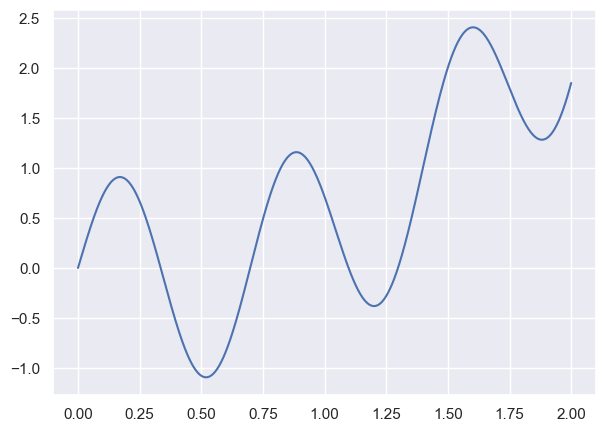

In [2]:
# set up true objective
def f1(x):
    return np.sin(9*x) + x**2 - 0.7*x
    #return np.sin(9*x) + x**2 -0.7*x -0.2* x**3
bounds = (0, 2)
x_star = np.linspace(*bounds, 10000)
f_star = f1(x_star)
true_max = np.max(f_star)
true_max_location = x_star[np.argmax(f_star)]

plt.figure(figsize=(7,5))
plt.plot(x_star, f_star)

In [3]:
# define kenel
dim = 1
kern_signal = C(1.0, (1e-3, 1e3)) * Matern(
            length_scale=np.ones(dim),
            length_scale_bounds=(1e-2, 1e2),
            nu=2.5,
        )
kern_noise = WhiteKernel(
        noise_level=1e-6,
        noise_level_bounds=(1e-10, 1e1),
    )
kernel=kern_signal + kern_noise

# create starting data
std_noise = 0.3
np.random.seed(42)
n_init = 5
#x_init = np.random.uniform(low=bounds[0], high=bounds[1], size=n_init)
#x_init = np.linspace(bounds[0], bounds[1],n_init)
x_init = np.linspace(bounds[0], 1.25, 5)
print(x_init)
y_init = f1(x_init) + np.random.normal(0, std_noise, size=n_init)

# optimizer parameter -linear increase
n_iter = 30
g = 1
alpha_low = 0.5
acq_samples = 10
optimizer = bo.BayesianOptimizer(
    func = f1,
    kernel = kernel,
    bounds = np.array(bounds).reshape(dim, 2),
    g= np.ones(n_iter)*g,
    alpha = np.linspace(alpha_low, 1.0, n_iter),
    x_init = x_init.reshape(-1,dim),
    y_init = y_init.reshape(-1,1),
    xi = 0,
    n_iter= n_iter,
    acq_samples=acq_samples, # num starting points to optimize acquization
    random_state=42,

)

# run optimization
opt_result = optimizer.simulate_optimization(noise_std = std_noise, max_val=true_max, visualize=False, verbose= False)
print(opt_result)
linear_alpha_result = {"cumulative_regrets": np.sum(opt_result["inst_regrets"]),  "dataset_x": optimizer.X, "dataset_y": optimizer.Y, **opt_result}
alpha_result = {"linear_increase":linear_alpha_result}

[0.     0.3125 0.625  0.9375 1.25  ]


  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:03<00:00,  7.63it/s]

{'best_iteration_observed': 21, 'best_observed': 3.019925460875618, 'best_observed_x': array([1.60393468]), 'best_iteration_regret': 21, 'inst_regrets': array([1.34864386e+00, 1.37760003e+00, 2.94763787e+00, 1.50180289e+00,
       1.25094412e+00, 1.58333622e+00, 1.38276866e+00, 1.88653805e+00,
       1.38247874e+00, 1.52887241e+00, 5.56816695e-01, 1.03319478e+00,
       1.12380536e+00, 8.93073587e-01, 8.26829929e-01, 1.06718969e+00,
       5.56816695e-01, 5.56816695e-01, 5.56816695e-01, 5.56816695e-01,
       5.56816695e-01, 1.23663926e-04, 1.00028871e-02, 2.38691118e-02,
       1.76901959e-02, 2.75234859e-03, 1.50338451e+00, 1.02047119e-02,
       1.24619416e-02, 8.25598128e-04])}


In [4]:
# optimizer parameter linear decrease
g = 1
optimizer = bo.BayesianOptimizer(
    func = f1,
    kernel = kernel,
    bounds = np.array(bounds).reshape(dim, 2),
    g= np.ones(n_iter)*g,
    alpha = np.linspace(1, alpha_low, n_iter),
    x_init = x_init.reshape(-1,dim),
    y_init = y_init.reshape(-1,1),
    xi = 0,
    n_iter= n_iter,
    acq_samples=acq_samples, # num starting points to optimize acquization
    random_state=42,

)

# run optimization
opt_result = optimizer.simulate_optimization(noise_std = std_noise, max_val=true_max, verbose= False)
print(opt_result)
linear_alpha_result = {"cumulative_regrets": np.sum(opt_result["inst_regrets"]),  "dataset_x": optimizer.X, "dataset_y": optimizer.Y, **opt_result}
alpha_result["linear_decay"] = linear_alpha_result

  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:04<00:00,  6.93it/s]

{'best_iteration_observed': 27, 'best_observed': 2.5304847756856237, 'best_observed_x': array([1.65623034]), 'best_iteration_regret': 29, 'inst_regrets': array([1.34864385, 1.37767318, 2.94765363, 1.5303084 , 1.24966418,
       1.41537299, 1.86928015, 2.38917756, 0.5568167 , 0.5568167 ,
       0.5568167 , 1.07931164, 0.5568167 , 0.5568167 , 0.5568167 ,
       0.5568167 , 1.0899821 , 1.03637759, 0.71508403, 0.68711086,
       1.06701593, 1.12346415, 1.11969858, 0.5568167 , 0.5568167 ,
       0.5568167 , 0.08663824, 0.10342   , 0.01711521, 0.00529028])}


In [5]:

# color
def plot_bo_color(true_x, true_y, data_x, data_y, title):
    n_color = data_y.shape[0]
    plt.figure(figsize=(8,4))
    plt.plot(true_x, true_y, 'k-', label='true f(x)')
    sc = plt.scatter(optimizer.X[n_init:], optimizer.Y[n_init:], c=np.arange(n_color), cmap='viridis', s=60, edgecolor='k')
    plt.colorbar(sc, label='iteration index')
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(title)
    plt.show()

In [6]:
# by number
def plot_bo_number(true_x, true_y, data_x, data_y, title):
    plt.figure(figsize=(8,4))
    plt.plot(true_x, true_y, 'k-', alpha=0.5)
    plt.scatter(data_x, data_y, c='C1', s=50, edgecolor='k')
    for i,(x,y) in enumerate(zip(data_x,data_y)):
        plt.text(x, y, str(i), color='black',
                fontsize=9, ha='center', va='bottom')
    plt.xlabel('x'); plt.ylabel('f(x)')
    plt.title(title)
    plt.show()

/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
  3%|▎         | 1/30 [00:00<00:05,  5.25it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasi

{'best_iteration_observed': 25, 'best_observed': 2.3236242081174576, 'best_observed_x': array([2.]), 'best_iteration_regret': 24, 'inst_regrets': array([1.37059518, 2.40969065, 2.57288606, 1.34669042, 1.34301513,
       1.48140034, 1.39206338, 1.41011049, 1.48552154, 1.66083161,
       1.73513121, 1.25360206, 1.24829504, 1.26188296, 1.28086841,
       1.27914315, 1.27251825, 1.32525626, 1.33099492, 1.40507575,
       1.28822789, 1.33679015, 1.47248962, 1.31227084, 0.5568167 ,
       0.5568167 , 1.7155061 , 0.5568167 , 0.5568167 , 0.5568167 ])}


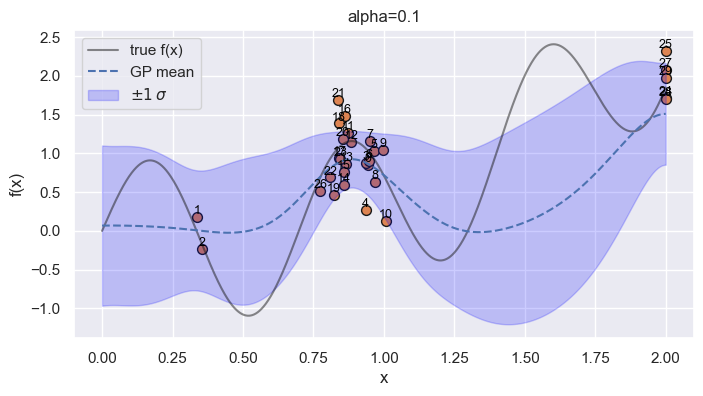

/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
  3%|▎         | 1/30 [00:00<00:03,  7.78it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasi

{'best_iteration_observed': 21, 'best_observed': 2.463232429567395, 'best_observed_x': array([2.]), 'best_iteration_regret': 17, 'inst_regrets': array([1.37059538, 2.40969065, 2.58321893, 1.33735361, 1.32119949,
       1.57187478, 1.55365573, 1.44818206, 1.52710447, 1.25069133,
       1.25062277, 1.24896705, 1.25480605, 1.27266464, 1.27820208,
       1.2482666 , 1.25884988, 0.5568167 , 0.5568167 , 0.5568167 ,
       1.07037567, 0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 ,
       0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 , 1.12331117])}


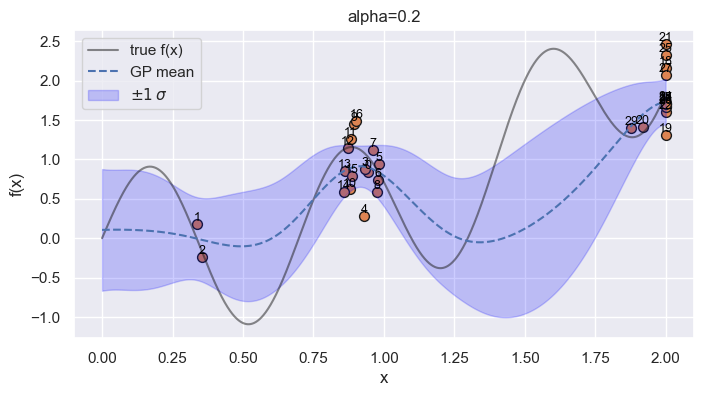

/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
  3%|▎         | 1/30 [00:00<00:03,  7.56it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasi

{'best_iteration_observed': 21, 'best_observed': 2.463232429567395, 'best_observed_x': array([2.]), 'best_iteration_regret': 16, 'inst_regrets': array([1.37059545, 2.40969065, 2.58898178, 1.32364571, 1.43441148,
       1.2484611 , 2.03056467, 1.25366378, 1.24921446, 1.25344866,
       1.25230429, 1.26476328, 1.27475425, 1.27430985, 0.72048534,
       0.9978737 , 0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 ,
       0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 ,
       0.5568167 , 1.60695367, 0.5568167 , 0.5568167 , 0.5568167 ])}


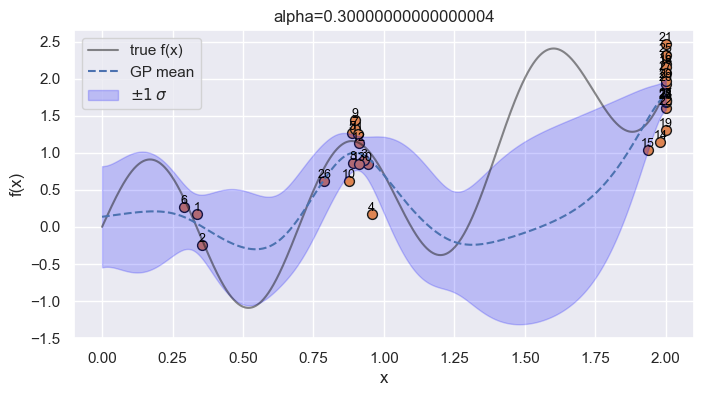

/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
  3%|▎         | 1/30 [00:00<00:03,  7.36it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasi

{'best_iteration_observed': 25, 'best_observed': 2.788887899036239, 'best_observed_x': array([1.65288829]), 'best_iteration_regret': 28, 'inst_regrets': array([1.37059548, 2.40969065, 2.59274163, 1.30766286, 1.47240539,
       1.24824311, 1.25088545, 1.25671916, 1.2526124 , 1.26446736,
       1.27934151, 1.27005   , 1.29450903, 1.34476766, 0.5568167 ,
       1.05765019, 0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 ,
       0.5568167 , 0.5568167 , 0.5568167 , 0.87007115, 0.0526515 ,
       0.091553  , 1.50903492, 0.05764963, 0.03701466, 0.09669516])}


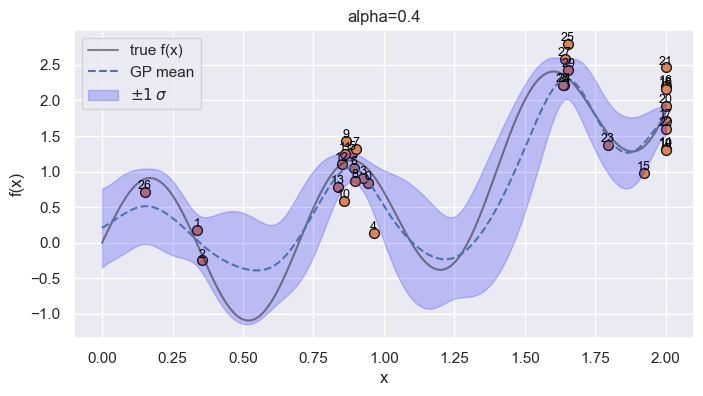

  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:04<00:00,  7.19it/s]


{'best_iteration_observed': 25, 'best_observed': 2.7859734482761165, 'best_observed_x': array([1.65372597]), 'best_iteration_regret': 28, 'inst_regrets': array([1.34864386e+00, 1.37758506e+00, 2.94763781e+00, 1.49482673e+00,
       1.25153028e+00, 1.60641291e+00, 1.38006555e+00, 1.38483832e+00,
       1.39104659e+00, 2.00395703e+00, 5.56816695e-01, 9.64388374e-01,
       1.11799315e+00, 5.56816695e-01, 5.56816695e-01, 1.06204532e+00,
       5.56816695e-01, 5.56816695e-01, 5.56816695e-01, 5.56816695e-01,
       5.56816695e-01, 5.56816695e-01, 5.56816695e-01, 3.72770802e-01,
       4.95707699e-01, 9.44674551e-02, 1.50922063e+00, 2.76521180e-03,
       9.74695734e-06, 5.03954094e-03])}


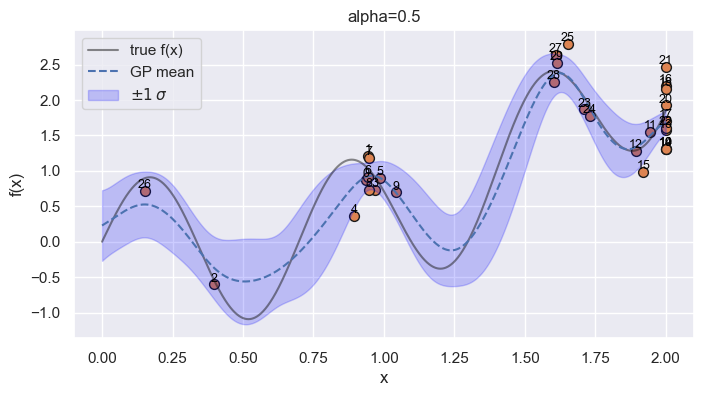

  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:03<00:00,  7.70it/s]


{'best_iteration_observed': 25, 'best_observed': 2.802261615639237, 'best_observed_x': array([1.6488815]), 'best_iteration_regret': 28, 'inst_regrets': array([1.34864386e+00, 1.37761579e+00, 2.94763902e+00, 1.50723849e+00,
       1.25077493e+00, 1.55042879e+00, 1.76375736e+00, 1.37866834e+00,
       1.37833447e+00, 1.54373937e+00, 1.49816409e+00, 1.65589430e+00,
       1.57155668e+00, 1.38246739e+00, 7.20485342e-01, 1.07173721e+00,
       5.56816695e-01, 5.56816695e-01, 5.56816695e-01, 5.56816695e-01,
       5.56816695e-01, 2.75506890e-01, 2.23877540e-01, 4.98749039e-01,
       7.17646435e-02, 7.81792877e-02, 1.64416362e+00, 9.06133413e-03,
       1.93846392e-03, 1.83336348e-02])}


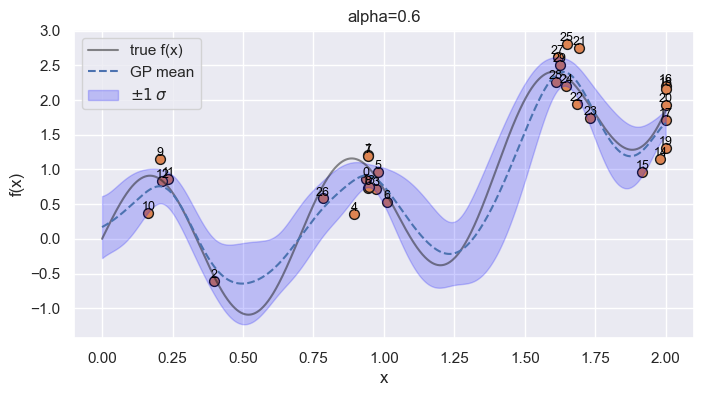

  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:04<00:00,  7.05it/s]


{'best_iteration_observed': 25, 'best_observed': 2.8724419994955177, 'best_observed_x': array([1.58768129]), 'best_iteration_regret': 25, 'inst_regrets': array([1.34864386, 1.37762453, 2.94764232, 1.51612265, 1.25029051,
       1.47155469, 1.7715566 , 1.36705861, 2.33808347, 1.5699877 ,
       1.49997652, 0.92209007, 0.88367227, 1.01857508, 0.72456542,
       1.12254413, 0.89260319, 0.89334803, 1.72364686, 0.89208863,
       0.5568167 , 0.5568167 , 0.5568167 , 0.05591887, 0.03337582,
       0.0079989 , 1.69284133, 0.08622187, 0.05963646, 0.02130185])}


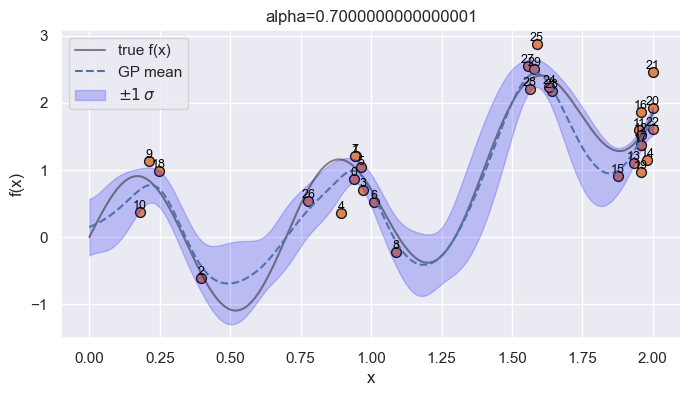

  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:03<00:00,  7.55it/s]


{'best_iteration_observed': 21, 'best_observed': 2.463232429567395, 'best_observed_x': array([2.]), 'best_iteration_regret': 11, 'inst_regrets': array([1.34864386, 1.37765142, 2.94764463, 1.5228629 , 1.24995886,
       1.43717388, 1.36238054, 1.93374207, 0.9534601 , 0.75614646,
       0.65435714, 0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 ,
       0.5568167 , 1.04510264, 1.12040115, 0.5568167 , 0.5568167 ,
       0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 , 0.5568167 ,
       0.5568167 , 1.51966508, 0.5568167 , 0.5568167 , 0.5568167 ])}


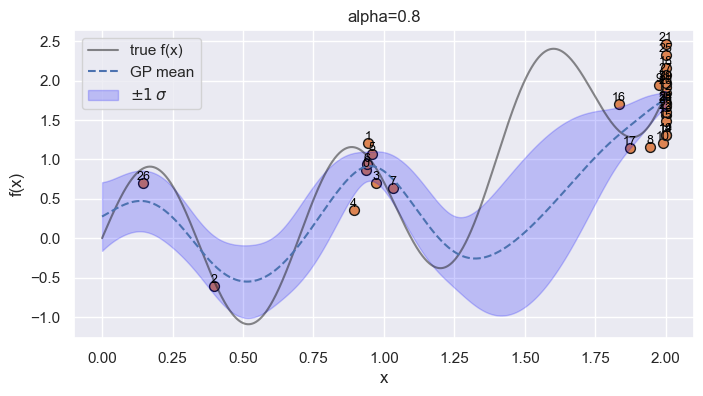

  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:03<00:00,  8.01it/s]


{'best_iteration_observed': 21, 'best_observed': 3.0199225947065163, 'best_observed_x': array([1.60395553]), 'best_iteration_regret': 21, 'inst_regrets': array([1.34864386e+00, 1.37763587e+00, 2.94764016e+00, 1.52809476e+00,
       1.24971950e+00, 1.41927582e+00, 1.86337654e+00, 2.38232310e+00,
       1.59794638e+00, 1.50257004e+00, 1.54062745e+00, 9.22090074e-01,
       1.37033036e+00, 9.22090067e-01, 1.11683023e+00, 5.56816695e-01,
       5.56816695e-01, 5.56816695e-01, 5.56816695e-01, 5.56816695e-01,
       5.56816695e-01, 1.26530095e-04, 1.36745407e-03, 4.89432815e-02,
       3.50561065e-02, 5.52216386e-04, 2.64629772e+00, 1.61071914e-03,
       2.21881197e-03, 3.57528854e-04])}


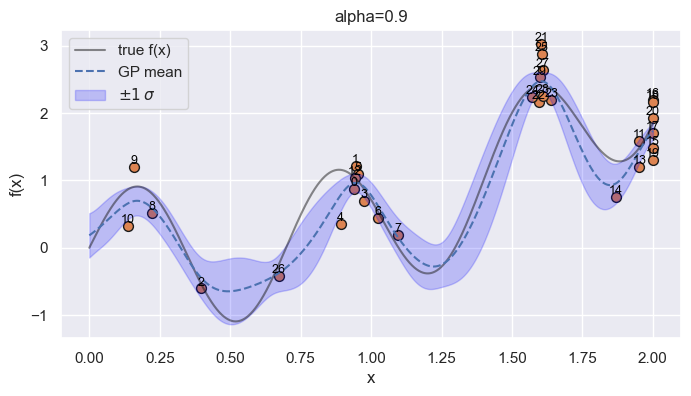

  0%|          | 0/30 [00:00<?, ?it/s]/Users/jiguangli/opt/anaconda3/envs/bo/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
100%|██████████| 30/30 [00:03<00:00,  7.89it/s]


{'best_iteration_observed': 21, 'best_observed': 2.9507666337397516, 'best_observed_x': array([1.64604242]), 'best_iteration_regret': 23, 'inst_regrets': array([1.34864385e+00, 1.37767328e+00, 2.94765383e+00, 1.53239640e+00,
       1.24954101e+00, 1.40810367e+00, 1.89181284e+00, 1.61539554e+00,
       1.50999043e+00, 1.34194480e+00, 1.33526096e+00, 1.76693637e+00,
       1.40233658e+00, 1.40863048e+00, 7.20485342e-01, 1.09610035e+00,
       5.56816695e-01, 5.56816695e-01, 5.56816695e-01, 5.56816695e-01,
       5.56816695e-01, 6.92824911e-02, 4.11051778e-02, 2.58108666e-03,
       1.97901368e-01, 3.45376230e-02, 1.65226181e+00, 2.50715947e-02,
       1.96337908e-02, 3.87537968e-02])}


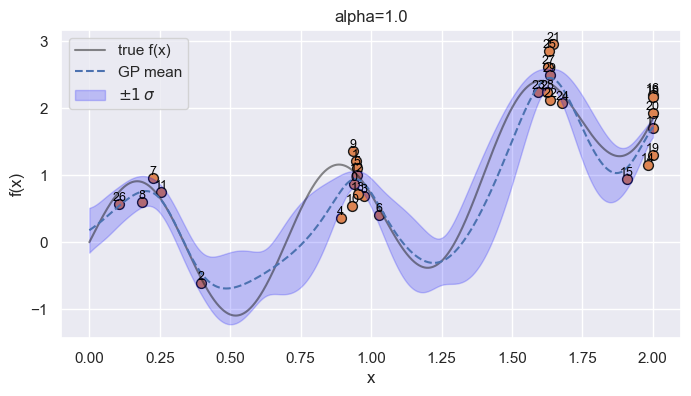

100%|██████████| 30/30 [00:04<00:00,  7.05it/s]


{'best_iteration_observed': 21, 'best_observed': 1.617713664975208, 'best_observed_x': array([0.82310535]), 'best_iteration_regret': 14, 'inst_regrets': array([1.34864385, 1.40585107, 2.94775274, 1.36607358, 1.36668666,
       1.36770318, 1.36748983, 1.36867879, 1.37043507, 1.37481555,
       1.38221214, 1.50234314, 1.49600052, 1.67492512, 1.25735258,
       1.26065621, 1.9285427 , 2.0476452 , 1.37516263, 1.36051979,
       1.37644089, 1.40233546, 1.48009791, 1.41832256, 1.48185764,
       1.56481417, 1.68027533, 1.63413204, 1.77172528, 2.355516  ])}


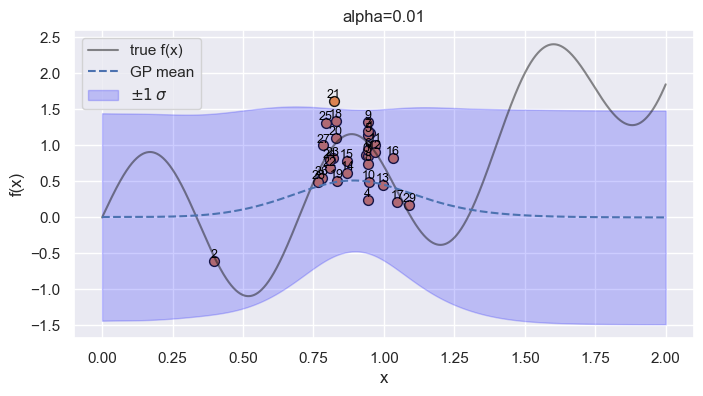

In [7]:
# RUN FOR ALL ALPHAS
all_alphas = np.arange(0.1, 1.1, 0.1)
all_alphas= np.append(all_alphas, 0.01)
for alpha in all_alphas:
    optimizer = bo.BayesianOptimizer(
        func = f1,
        kernel = kernel,
        bounds = np.array(bounds).reshape(dim, 2),
        g= np.ones(n_iter)*g,
        alpha = np.ones(n_iter)* alpha,
        x_init = x_init.reshape(-1,dim),
        y_init = y_init.reshape(-1,1),
        xi = 0,
        n_iter= n_iter,
        acq_samples=acq_samples, # num starting points to optimize acquization
        random_state=42
    )
    opt_result = optimizer.simulate_optimization(noise_std = std_noise, max_val=true_max, verbose= False)
    print(opt_result)
    temp_result = {"cumulative_regrets": np.sum(opt_result["inst_regrets"]),  "dataset_x": optimizer.X, "dataset_y": optimizer.Y, **opt_result}
    alpha_result[alpha] = temp_result
    # visualize
    plt.figure(figsize=(8,4))
    plt.plot(x_star, f_star, 'k-', label='true f(x)', alpha=0.5)
    data_x, data_y = optimizer.X[n_init:], optimizer.Y[n_init:]
    plt.scatter(data_x, data_y, c='C1', s=50, edgecolor='k')
    for i,(x,y) in enumerate(zip(data_x,data_y)):
        plt.text(x, y, str(i), color='black',
                fontsize=9, ha='center', va='bottom')
    plt.xlabel('x'); plt.ylabel('f(x)')
    plt.title(f"alpha={alpha}")
    mu, std = optimizer.predict_tempered(x_star.reshape(-1, 1),alpha)
    plt.plot(x_star, mu, 'b--', label='GP mean')
    # ±1σ band
    plt.fill_between(
        x_star.ravel(),
        (mu - std).ravel(),
        (mu + std).ravel(),
        color='blue',
        alpha=0.2,
        label=r'$\pm1\,\sigma$'
    )
    plt.legend()
    plt.show()
    #plot_bo_number(x_star, f_star, optimizer.X[n_init:], optimizer.Y[n_init:], title= f"expected_improvement: alpha={alpha}")


In [8]:
alpha_result.keys()

dict_keys(['linear_increase', 'linear_decay', 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7000000000000001, 0.8, 0.9, 1.0, 0.01])

In [9]:
alpha_result["linear_decay"].keys()

dict_keys(['cumulative_regrets', 'dataset_x', 'dataset_y', 'best_iteration_observed', 'best_observed', 'best_observed_x', 'best_iteration_regret', 'inst_regrets'])

In [10]:
cols = ['cumulative_regrets', 'best_iteration_observed', 'best_observed', 'best_observed_x', 'best_iteration_regret']
alpha_result_df = pd.DataFrame({
    key: {c: sub.get(c, None) for c in cols}
    for key, sub in alpha_result.items()
}).T

In [11]:
alpha_result_df

,cumulative_regrets,best_iteration_observed,best_observed,best_observed_x,best_iteration_regret
linear_increase,26.056931,21,3.019925,[1.6039346815344777],21
linear_decay,27.82645,27,2.530485,[1.6562303353373669],29
0.1,39.774941,25,2.323624,[2.0],24
0.2,33.504616,21,2.463232,[2.0],17
0.3,31.792739,21,2.463232,[2.0],16
0.4,28.841545,25,2.788888,[1.6528882876513187],28
0.5,27.379119,25,2.785973,[1.6537259652085199],28
0.6,29.552803,25,2.802262,[1.6488814958741023],28
0.7,31.15942,25,2.872442,[1.5876812860451532],25
0.8,28.138258,21,2.463232,[2.0],11
